# 04 — Zero-Shot Evaluation (ESM-2 Log-Ratio)

This notebook evaluates the **ESM-2 log-ratio** as a zero-shot predictor of missense variant
pathogenicity, using **ROC-AUC and PR-AUC computed per gene**.

## Design decisions

- **Score:** `esm2_log_ratio` only. Prot-T5 will be evaluated separately after delta-embedding
  extraction (methodological asymmetry with ESM-2 log-ratio; see notebook 03).
- **Gene set:** assessable genes only (≥ 5 variants with both classes represented).
- **Aggregation:** median ROC-AUC and PR-AUC across genes (primary), plus mean weighted
  by number of variants per gene (secondary).
- **Sign convention:** a *more negative* log-ratio means the mutant residue is less compatible
  with the sequence context → predicted pathogenic. The score is therefore **negated** before
  passing to `roc_auc_score` so that higher values correspond to higher pathogenicity.

## Output

- `data/processed/zeroshot_gene_metrics.parquet` — per-gene ROC-AUC, PR-AUC, n_variants,
  n_pathogenic, n_benign, prevalence.
- Summary statistics and stratified analysis printed inline.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bio_var_pred.embeddings.assess import is_assessable
from bio_var_pred.metrics.compute import compute_gene_metrics, compute_gene_baseline
from bio_var_pred.utils.paths import PROCESSED_DATA_DIR

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_SEED = 42

## 1. Load data and reproduce assessability filter

In [2]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "variants_with_scores.parquet")
print(f"Full dataset loaded : {df.shape}")

# Re-apply assessability filter (≥ 5 variants with both classes)
assessable_df = (
    df
    .dropna(subset=["esm2_log_ratio"])
    .groupby("gene")
    .filter(is_assessable)
    .reset_index(drop=True)
)

print(f"Assessable variants : {len(assessable_df)}")
print(f"Assessable genes    : {assessable_df['gene'].nunique()}")

Full dataset loaded : (54821, 18)
Assessable variants : 54821
Assessable genes    : 2252


## 2. Sign convention check

The ESM-2 log-ratio is defined as `logP(mut|context) - logP(wt|context)`.  
A *more negative* score means the model considers the mutant residue less compatible with the
sequence context — i.e., more likely to be deleterious.  
We therefore expect **pathogenic variants (label=1) to have lower (more negative) scores**
than benign variants (label=0).

Verify before negating:

In [3]:
sign_check = assessable_df.groupby("label")["esm2_log_ratio"].median()
print("Median log-ratio per class:")
sign_check.rename({0: "Benign", 1: "Pathogenic"})

Median log-ratio per class:


label
Benign        -4.207634
Pathogenic   -10.195123
Name: esm2_log_ratio, dtype: float64

In [4]:
if sign_check[1] < sign_check[0]:
    print("✓ Convention confirmed: pathogenic < benign. Negating score for AUC computation.")
    NEGATE = True
else:
    print("⚠ Unexpected sign — pathogenic NOT lower than benign. Check score computation.")
    NEGATE = False

✓ Convention confirmed: pathogenic < benign. Negating score for AUC computation.


## 3. Per-gene ROC-AUC and PR-AUC

In [5]:
gene_metrics = (
    assessable_df
        .groupby("gene", observed=True)
        .apply(compute_gene_metrics, negate=NEGATE)
        .reset_index()
)

print(f"Gene metrics computed for {len(gene_metrics)} genes.")
gene_metrics.head(10)

Gene metrics computed for 2252 genes.


,gene,n_variants,n_pathogenic,n_benign,prevalence,roc_auc,pr_auc
0,A4GALT,5.0,1.0,4.0,0.200000,0.750000,0.500000
1,AAAS,14.0,9.0,5.0,0.642857,0.822222,0.930014
2,AARS1,15.0,7.0,8.0,0.466667,0.982143,0.982143
3,AARS2,22.0,10.0,12.0,0.454545,0.916667,0.913929
4,AASS,6.0,2.0,4.0,0.333333,0.625000,0.700000
5,ABAT,10.0,8.0,2.0,0.800000,1.000000,1.000000
6,ABCA1,33.0,9.0,24.0,0.272727,0.972222,0.932884
7,ABCA12,40.0,11.0,29.0,0.275000,0.981191,0.956277
8,ABCA3,27.0,19.0,8.0,0.703704,0.907895,0.958548
9,ABCA4,374.0,364.0,10.0,0.973262,0.916758,0.997592


## 4. Global summary statistics

In [6]:
def weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    return float(np.average(values, weights=weights))


for metric in ["roc_auc", "pr_auc"]:
    med = gene_metrics[metric].median()
    q25 = gene_metrics[metric].quantile(0.25)
    q75 = gene_metrics[metric].quantile(0.75)
    w_mean = weighted_mean(gene_metrics[metric], gene_metrics["n_variants"])

    print(f"{metric.upper()}")
    print(f"\tMedian (IQR)\t: {med:.3f}  [{q25:.3f} – {q75:.3f}]")
    print(f"\tWeighted mean\t: {w_mean:.3f}")
    print(f"\tMin / Max\t\t: {float(gene_metrics[metric].min()):.3f} / {float(gene_metrics[metric].max()):.3f}")

ROC_AUC
	Median (IQR)	: 0.951  [0.821 – 1.000]
	Weighted mean	: 0.878
	Min / Max		: 0.000 / 1.000
PR_AUC
	Median (IQR)	: 0.983  [0.833 – 1.000]
	Weighted mean	: 0.861
	Min / Max		: 0.005 / 1.000


## 5. Stratified analysis by gene size

Genes are split into three strata by number of annotated variants to examine how performance
varies with data availability — the central question of the low-data regime analysis.

In [7]:
# Define strata
bins = [0, 10, 50, np.inf]
labels = ["5–10", "11–50", ">50"]

gene_metrics["stratum"] = pd.cut(
    gene_metrics["n_variants"],
    bins=bins,
    labels=labels,
    right=True
)

strata_summary = (
    gene_metrics
        .groupby("stratum", observed=True)
        .agg(
            n_genes       = ("gene",    "count"),
            n_variants    = ("n_variants", "sum"),
            median_roc_auc = ("roc_auc",  "median"),
            q25_roc_auc   = ("roc_auc",  lambda x: x.quantile(0.25)),
            q75_roc_auc   = ("roc_auc",  lambda x: x.quantile(0.75)),
            median_pr_auc  = ("pr_auc",   "median"),
            q25_pr_auc    = ("pr_auc",   lambda x: x.quantile(0.25)),
            q75_pr_auc    = ("pr_auc",   lambda x: x.quantile(0.75)),
        )
        .reset_index()
)

print(strata_summary.to_string(index=False))

stratum  n_genes  n_variants  median_roc_auc  q25_roc_auc  q75_roc_auc  median_pr_auc  q25_pr_auc  q75_pr_auc
   5–10      958      6805.0        1.000000     0.800000     1.000000       1.000000    0.833333     1.00000
  11–50     1069     22195.0        0.942857     0.824324     1.000000       0.969798    0.813326     1.00000
    >50      225     25821.0        0.923729     0.835821     0.971326       0.976955    0.870019     0.99643


## 6. Figures

### 6.1 Distribution of per-gene ROC-AUC

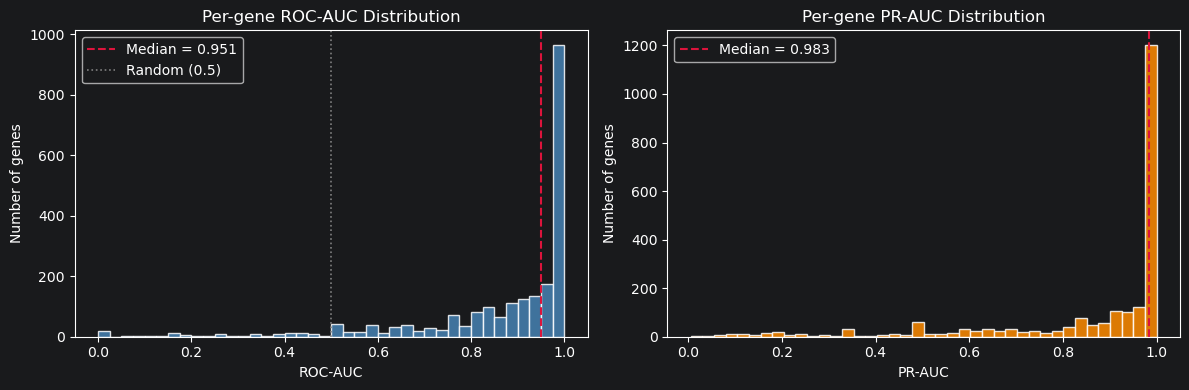

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC-AUC histogram
axes[0].hist(gene_metrics["roc_auc"], bins=40, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].axvline(
    gene_metrics["roc_auc"].median(),
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f'Median = {gene_metrics["roc_auc"].median():.3f}'
)
axes[0].axvline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Random (0.5)")
axes[0].set_title("Per-gene ROC-AUC Distribution")
axes[0].set_xlabel("ROC-AUC")
axes[0].set_ylabel("Number of genes")
axes[0].legend()

# PR-AUC histogram
axes[1].hist(gene_metrics["pr_auc"], bins=40, color="darkorange", alpha=0.85, edgecolor="white")
axes[1].axvline(
    gene_metrics["pr_auc"].median(),
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label=f'Median = {gene_metrics["pr_auc"].median():.3f}'
)
axes[1].set_title("Per-gene PR-AUC Distribution")
axes[1].set_xlabel("PR-AUC")
axes[1].set_ylabel("Number of genes")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED_DATA_DIR / "fig_auc_distributions.pdf", bbox_inches="tight")
plt.show()

### 6.2 ROC-AUC by gene stratum (box plot)

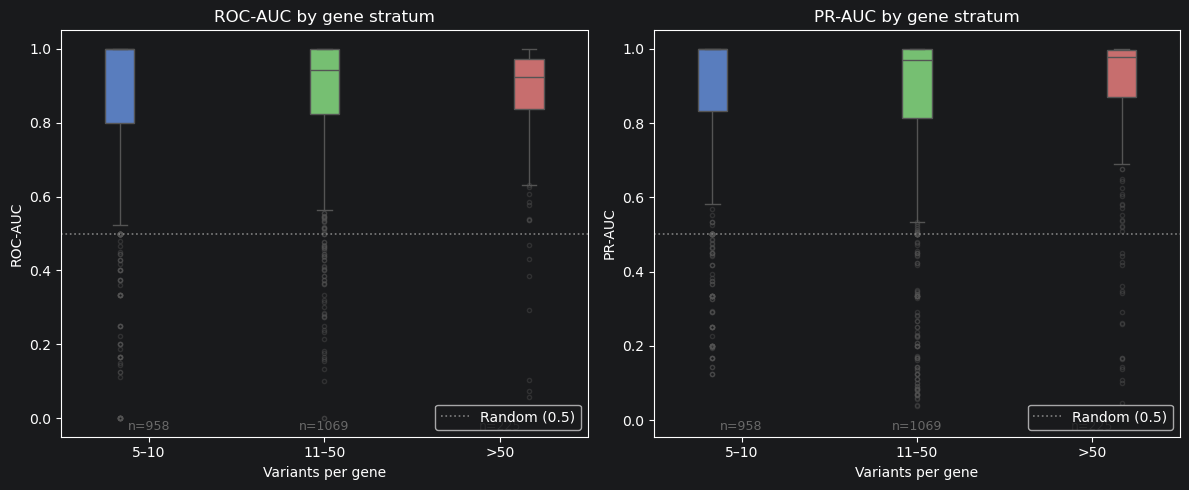

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

palette = {"5–10": "#4878CF", "11–50": "#6ACC65", ">50": "#D65F5F"}

for ax, metric, title in zip(
    axes,
    ["roc_auc", "pr_auc"],
    ["ROC-AUC by gene stratum", "PR-AUC by gene stratum"]
):
    sns.boxplot(
        data=gene_metrics,
        x="stratum",
        y=metric,
        hue="stratum",
        order=labels,
        palette=palette,
        width=0.5,
        flierprops=dict(marker="o", markersize=3, alpha=0.4),
        ax=ax,
        legend=False
    )
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Random (0.5)")
    ax.set_title(title)
    ax.set_xlabel("Variants per gene")
    ax.set_ylabel(metric.upper().replace("_", "-"))

    # Annotate with gene counts per stratum
    for i, stratum in enumerate(labels):
        n = strata_summary.loc[strata_summary["stratum"] == stratum, "n_genes"].array[0]
        ax.text(i, ax.get_ylim()[0] + 0.01, f"n={n}", ha="center", va="bottom", fontsize=9, color="dimgray")

    ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig(PROCESSED_DATA_DIR / "fig_auc_by_stratum.pdf", bbox_inches="tight")
plt.show()

### 6.3 ROC-AUC vs. number of variants per gene (scatter)

Examines whether gene size predicts performance — a key question for the low-data regime.

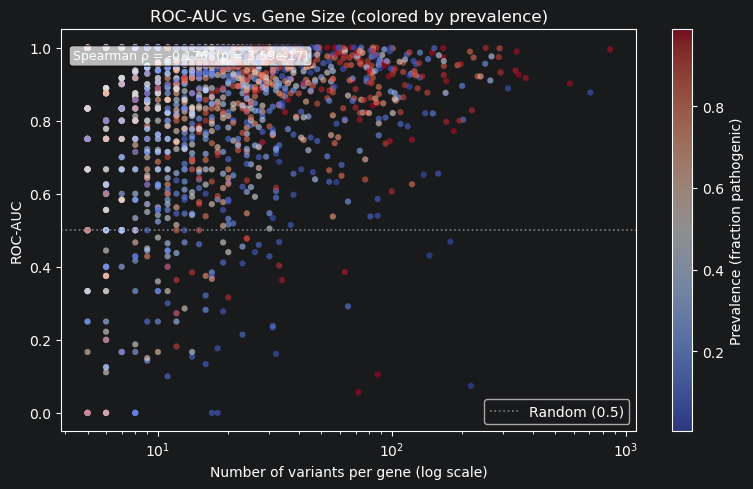

Spearman ρ (n_variants vs ROC-AUC) = -0.176  (p = 3.59e-17)


In [10]:
from scipy.stats import spearmanr


fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    gene_metrics["n_variants"],
    gene_metrics["roc_auc"],
    c=gene_metrics["prevalence"],
    cmap="coolwarm",
    alpha=0.6,
    s=20,
    edgecolors="none"
)
plt.colorbar(scatter, ax=ax, label="Prevalence (fraction pathogenic)")
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Random (0.5)")
ax.set_xscale("log")
ax.set_xlabel("Number of variants per gene (log scale)")
ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC vs. Gene Size (colored by prevalence)")

# Spearman correlation
rho, pval = spearmanr(gene_metrics["n_variants"], gene_metrics["roc_auc"])
ax.text(
    0.02,
    0.95,
    f"Spearman ρ = {rho:.3f}  (p = {pval:.2e})",
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)

ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(PROCESSED_DATA_DIR / "fig_roc_vs_genesize.pdf", bbox_inches="tight")
plt.show()

print(f"Spearman ρ (n_variants vs ROC-AUC) = {rho:.3f}  (p = {pval:.2e})")

### 6.4 ROC-AUC vs. prevalence

PR-AUC is sensitive to class imbalance (it scales with prevalence). This plot checks whether
apparent PR-AUC variation across genes is driven by prevalence rather than by model quality.

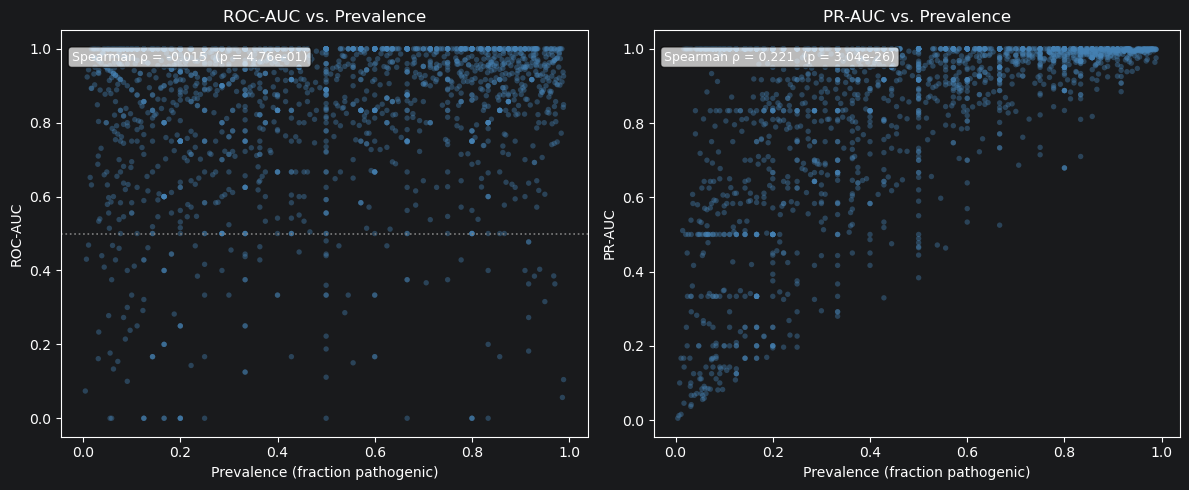

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric in zip(axes, ["roc_auc", "pr_auc"]):
    ax.scatter(
        gene_metrics["prevalence"],
        gene_metrics[metric],
        alpha=0.4, s=15, edgecolors="none", color="steelblue"
    )
    rho, pval = spearmanr(gene_metrics["prevalence"], gene_metrics[metric])
    ax.set_xlabel("Prevalence (fraction pathogenic)")
    ax.set_ylabel(metric.upper().replace("_", "-"))
    ax.set_title(f"{metric.upper().replace('_','-')} vs. Prevalence")
    ax.text(
        0.02,
        0.95,
        f"Spearman ρ = {rho:.3f}  (p = {pval:.2e})",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
    )

axes[0].axhline(0.5, color="gray", linestyle=":", linewidth=1.2)

plt.tight_layout()
plt.savefig(PROCESSED_DATA_DIR / "fig_auc_vs_prevalence.pdf", bbox_inches="tight")
plt.show()

## 7. Top and bottom performing genes

In [12]:
TOP_N = 10

display_cols = ["gene", "n_variants", "n_pathogenic", "n_benign", "prevalence", "roc_auc", "pr_auc", "stratum"]

print(f"Top {TOP_N} genes by ROC-AUC:")
print(
    gene_metrics.nlargest(TOP_N, "roc_auc")[display_cols].to_string(index=False, float_format="{:.3f}")
)
print()
print(f"Bottom {TOP_N} genes by ROC-AUC:")
print(
    gene_metrics.nsmallest(TOP_N, "roc_auc")[display_cols].to_string(index=False, float_format="{:.3f}")
)

Top 10 genes by ROC-AUC:
      gene  n_variants  n_pathogenic  n_benign  prevalence  roc_auc  pr_auc stratum
      ABAT      10.000         8.000     2.000       0.800    1.000   1.000    5–10
     ABCB1       8.000         1.000     7.000       0.125    1.000   1.000    5–10
     ABCC9      18.000        15.000     3.000       0.833    1.000   1.000   11–50
     ABCG5      10.000         4.000     6.000       0.400    1.000   1.000    5–10
     ABCG8      12.000         3.000     9.000       0.250    1.000   1.000   11–50
AC020929.1      10.000         1.000     9.000       0.100    1.000   1.000    5–10
    ACADSB      10.000         7.000     3.000       0.700    1.000   1.000    5–10
     ACAT1      22.000        21.000     1.000       0.955    1.000   1.000   11–50
     ACOX1       9.000         4.000     5.000       0.444    1.000   1.000    5–10
     ACVR1      13.000         8.000     5.000       0.615    1.000   1.000   11–50

Bottom 10 genes by ROC-AUC:
  gene  n_variants  n_

## 8. Baseline comparison: random predictor and log_af alone

A random predictor has expected ROC-AUC = 0.5.  
`log_af` (population allele frequency) is a simple non-model baseline: rarer variants tend to
be pathogenic, so *more negative* `log_af` predicts pathogenicity.

> **Note on ascertainment bias:** `log_af` may appear artificially informative because ClinVar
> tends to curate rare variants as pathogenic. This circularity is acknowledged as a limitation
> of the dataset.

In [13]:
baseline_metrics = (
    assessable_df
        .groupby("gene", observed=True)
        .apply(compute_gene_baseline)
        .reset_index()
)

gene_metrics = gene_metrics.merge(baseline_metrics, on="gene", how="left")

print("Baseline (log_af) vs ESM-2 log-ratio — median ROC-AUC per gene:")
print(f"  ESM-2 log-ratio\t: {gene_metrics['roc_auc'].median():.3f}")
print(f"  log_af baseline\t: {gene_metrics['roc_auc_logaf'].median():.3f}")
print(f"  Random\t\t\t: 0.500")

Baseline (log_af) vs ESM-2 log-ratio — median ROC-AUC per gene:
  ESM-2 log-ratio	: 0.951
  log_af baseline	: 0.500
  Random			: 0.500


### 8.1 Paired comparison: ESM-2 vs log_af per gene

Wilcoxon signed-rank test (ESM-2 vs log_af, n=2252 genes):
  statistic = 118039.0
  p-value = 2.92e-289



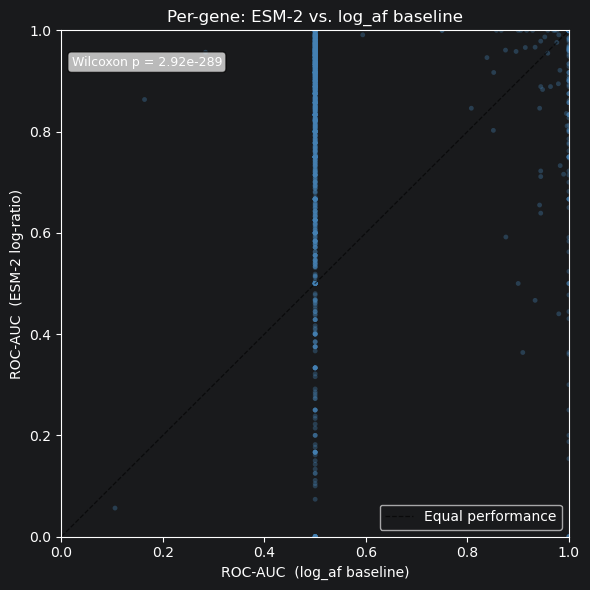

In [14]:
from scipy.stats import wilcoxon

paired = gene_metrics[["roc_auc", "roc_auc_logaf"]].dropna()
stat, pval = wilcoxon(paired["roc_auc"], paired["roc_auc_logaf"], alternative="two-sided")

print(f"Wilcoxon signed-rank test (ESM-2 vs log_af, n={len(paired)} genes):")
print(f"  statistic = {stat:.1f}")
print(f"  p-value = {pval:.2e}")
print()

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(
    gene_metrics["roc_auc_logaf"],
    gene_metrics["roc_auc"],
    alpha=0.35, s=12, edgecolors="none", color="steelblue"
)
lims = 0, 1
ax.plot(lims, lims, "k--", linewidth=0.9, alpha=0.6, label="Equal performance")
ax.set_xlabel("ROC-AUC  (log_af baseline)")
ax.set_ylabel("ROC-AUC  (ESM-2 log-ratio)")
ax.set_title("Per-gene: ESM-2 vs. log_af baseline")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend()
ax.text(
    0.02,
    0.95,
    f"Wilcoxon p = {pval:.2e}",
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7)
)
plt.tight_layout()
plt.savefig(PROCESSED_DATA_DIR / "fig_esm2_vs_logaf.pdf", bbox_inches="tight")
plt.show()

## 9. Save per-gene metrics

In [15]:
output_path = PROCESSED_DATA_DIR / "zeroshot_gene_metrics.parquet"
gene_metrics.to_parquet(output_path, index=False)

print(f"Saved: {output_path}")
print(f"Shape: {gene_metrics.shape}")
print(f"Columns: {list(gene_metrics.columns)}")

Saved: /Users/dcanevarollo/Desktop/Projetos/Unesp/ia/bio-variant-prediction/data/processed/zeroshot_gene_metrics.parquet
Shape: (2252, 10)
Columns: ['gene', 'n_variants', 'n_pathogenic', 'n_benign', 'prevalence', 'roc_auc', 'pr_auc', 'stratum', 'roc_auc_logaf', 'pr_auc_logaf']
